# Exploring Expectiles: A Unified Risk Measure Under Tail Variation

This experiment investigates **expectiles** as a risk measure framework that unifies and extends Value at Risk (VaR) and Conditional Tail Expectation (CTE). We visualize how expectiles evolve across a 100 $\times$ 100 grid of Pareto tail indices and expectile levels, revealing the risk landscape that traditional risk measures only partially illuminate.

## What Are Expectiles?

The **expectile** at level $\tau$ of a random variable $X$ is the unique value $e_\tau$ satisfying the asymmetric least squares condition:

$$\tau \, \mathbb{E}\!\left[(X - e_\tau)_+\right] = (1 - \tau) \, \mathbb{E}\!\left[(e_\tau - X)_+\right]$$

where $(x)_+ = \max(0, x)$. At $\tau = 0.5$, both sides receive equal weight, yielding the **mean**. As $\tau$ increases toward 1, the condition upweights losses exceeding $e_\tau$, pushing the expectile into the right tail. Expectiles generalize the mean in the same way that quantiles generalize the median.

The critical difference: **quantiles** depend only on the *frequency* of exceedance (how often losses exceed a threshold), while **expectiles** depend on the *magnitude* of exceedance (how large those losses are). This makes expectiles inherently more sensitive to tail behavior.

## Why Expectiles Matter for Risk Management

| Property | VaR (Quantile) | CTE / CVaR | Expectile ($\tau \geq 0.5$) |
|---|---|---|---|
| **Coherent** (subadditive) | No | Yes | Yes |
| **Elicitable** (backtestable) | Yes | No | Yes |
| **Tail-sensitive** | Frequency only | Magnitude (conditional) | Magnitude (global) |

- **VaR** is elicitable (you can rank forecasts with consistent scoring functions) but fails coherence: the VaR of a diversified portfolio can exceed the sum of individual VaRs, penalizing diversification.
- **CTE** (a.k.a. CVaR / Expected Shortfall) is coherent (diversification always helps) but fails elicitability: no scoring function consistently ranks CTE forecasts, making backtesting fundamentally unreliable (Gneiting, 2011).
- **Expectiles** are the *only* law-invariant (depend only on the loss distribution) risk measures that are both coherent *and* elicitable (Bellini & Bignozzi, 2015; Ziegel, 2016). This unique combination enables rigorous backtesting of a coherent risk measure, as demonstrated by de Ita Solis et al. (2026).

## Expectiles as a Unifying Framework

For any continuous loss distribution, every VaR at confidence level $p$ corresponds to a unique expectile level $\tau_{\text{VaR}}$ such that $e_{\tau_{\text{VaR}}} = \text{VaR}_p$, and similarly every CTE corresponds to a unique $\tau_{\text{CTE}}$. This mapping is **distribution-dependent**: as the tail index changes, the expectile levels needed to reproduce VaR and CTE shift, revealing how the tail reshapes the relationship between risk measures.

## Experiment Design

We use the same three-component compound-Poisson loss model as [Reconciliation Notebook 13](https://github.com/AlexFiliakov/Ergodic-Insurance-Limits/blob/main/ergodic_insurance/notebooks/reconciliation/13_risk_measures_compare.ipynb), varying only the catastrophic component's Pareto tail index $\alpha$ from 3.0 (thin tail) to 1.5 (heavy tail) while holding the mean constant. For each $\alpha$ we simulate 1,000,000 annual aggregate losses and compute expectiles across 100 levels from $\tau = 0.985$ to $\tau = 0.9999$, focusing on the deep-tail region where risk measures operate. VaR and CTE at the 99.5% confidence level are overlaid on the resulting heatmap.

In [1]:
"""Google Colab setup: mount Drive and install package dependencies.

Run this cell first. If prompted to restart the runtime, do so, then re-run all cells.
This cell is a no-op when running locally.
"""
import sys, os
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    NOTEBOOK_DIR = '/content/drive/My Drive/Colab Notebooks/ei_notebooks/reconciliation'

    os.chdir(NOTEBOOK_DIR)
    if NOTEBOOK_DIR not in sys.path:
        sys.path.append(NOTEBOOK_DIR)

    !pip install ergodic-insurance -q 2>&1 | tail -3
    print('\nSetup complete. If you see numpy/scipy import errors below,')
    print('restart the runtime (Runtime > Restart runtime) and re-run all cells.')

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm
import warnings, time, os

warnings.filterwarnings("ignore")

from ergodic_insurance.visualization.core import (
    set_wsj_style, WSJ_COLORS, COLOR_SEQUENCE,
)

SEED = 20260227
set_wsj_style()
os.makedirs('cache', exist_ok=True)
print("Setup complete.")

Setup complete.


## Loss Configuration

Three-component compound-Poisson loss model, extracted from [Optimization Notebook 12 (Deductible Optimization)](https://github.com/AlexFiliakov/Ergodic-Insurance-Limits/blob/main/ergodic_insurance/notebooks/optimization/12_vol_drag_vs_prem_drag.ipynb). Only the catastrophic component's tail parameters ($\alpha$, $x_m$) will vary; the attritional and large components remain fixed throughout.

In [3]:
# --- Loss Model Parameters (from Notebook 12: Deductible Optimization) ---
ATTR_BASE_FREQ = 5.0
ATTR_SEV_MEAN = 10_000
ATTR_SEV_CV = 3.0

LG_BASE_FREQ = 1.75
LG_SEV_MEAN = 375_000
LG_SEV_CV = 1.5

CAT_BASE_FREQ = 0.15
CAT_SEV_ALPHA_BASELINE = 2.01
CAT_SEV_XM_BASELINE = 1_500_000

# --- Lognormal severity parameters ---
attr_var = np.log(1 + ATTR_SEV_CV**2)
attr_mu = np.log(ATTR_SEV_MEAN) - attr_var / 2
attr_sig = np.sqrt(attr_var)

lg_var = np.log(1 + LG_SEV_CV**2)
lg_mu = np.log(LG_SEV_MEAN) - lg_var / 2
lg_sig = np.sqrt(lg_var)

# --- Catastrophic mean (held constant throughout the sweep) ---
CAT_MEAN = (CAT_SEV_ALPHA_BASELINE * CAT_SEV_XM_BASELINE
            / (CAT_SEV_ALPHA_BASELINE - 1))

# Component expected annual aggregate losses
attr_sev_mean = np.exp(attr_mu + attr_var / 2)
lg_sev_mean = np.exp(lg_mu + lg_var / 2)

total_expected = (ATTR_BASE_FREQ * attr_sev_mean
                  + LG_BASE_FREQ * lg_sev_mean
                  + CAT_BASE_FREQ * CAT_MEAN)

print("Loss Model (from Notebook 12: Deductible Optimization)")
print("=" * 65)
print(f"  Attritional:  \u03bb={ATTR_BASE_FREQ:.1f}  E[X]=${attr_sev_mean:>10,.0f}"
      f"  E[S]=${ATTR_BASE_FREQ * attr_sev_mean:>12,.0f}")
print(f"  Large:        \u03bb={LG_BASE_FREQ:.2f} E[X]=${lg_sev_mean:>10,.0f}"
      f"  E[S]=${LG_BASE_FREQ * lg_sev_mean:>12,.0f}")
print(f"  Catastrophic: \u03bb={CAT_BASE_FREQ:.2f} E[X]=${CAT_MEAN:>10,.0f}"
      f"  E[S]=${CAT_BASE_FREQ * CAT_MEAN:>12,.0f}")
print("  " + "\u2500" * 61)
print(f"  Total Expected Annual Loss:           ${total_expected:>12,.0f}")
print(f"\n  Catastrophic severity mean (held constant): ${CAT_MEAN:,.0f}")
print(f"  Baseline: \u03b1 = {CAT_SEV_ALPHA_BASELINE}, x_m = ${CAT_SEV_XM_BASELINE:,.0f}")

Loss Model (from Notebook 12: Deductible Optimization)
  Attritional:  λ=5.0  E[X]=$    10,000  E[S]=$      50,000
  Large:        λ=1.75 E[X]=$   375,000  E[S]=$     656,250
  Catastrophic: λ=0.15 E[X]=$ 2,985,149  E[S]=$     447,772
  ─────────────────────────────────────────────────────────────
  Total Expected Annual Loss:           $   1,154,022

  Catastrophic severity mean (held constant): $2,985,149
  Baseline: α = 2.01, x_m = $1,500,000


## Grid Design

We sweep two axes simultaneously:

- **Pareto tail index $\alpha$**: 100 values from 3.0 (thin tail, finite variance) to 1.5 (heavy tail, infinite variance). For each $\alpha$, the Pareto scale $x_m$ is adjusted to hold the catastrophic severity mean constant: $x_m(\alpha) = \bar{X}_{\text{cat}} \cdot \frac{\alpha - 1}{\alpha}$.

- **Expectile level $\tau$**: 100 values from 0.985 to 0.9999. This focuses on the deep-tail region where risk measures operate. VaR at 99.5% corresponds to approximately $\tau \approx 0.991$–$0.998$, and CTE at 99.5% to $\tau \approx 0.998$–$0.999$. (At $\tau = 0.5$ the expectile equals the mean, which is constant by construction and therefore uninformative for comparing tail behavior.)

The resulting 100 $\times$ 100 grid produces 10,000 expectile values, each computed from 1,000,000 simulated aggregate losses.

In [4]:
N_PARETO = 100
N_TAU = 100

PARETO_GRID = np.linspace(3.0, 1.5, N_PARETO)
TAU_GRID = np.linspace(0.985, 0.9999, N_TAU)
XM_GRID = CAT_MEAN * (PARETO_GRID - 1) / PARETO_GRID

print(f"Pareto \u03b1: {PARETO_GRID[0]:.2f} \u2192 {PARETO_GRID[-1]:.2f} ({N_PARETO} points)")
print(f"Expectile \u03c4: {TAU_GRID[0]:.4f} \u2192 {TAU_GRID[-1]:.4f} ({N_TAU} points)")
print(f"Grid size: {N_PARETO} \u00d7 {N_TAU} = {N_PARETO * N_TAU:,} expectile values")

Pareto α: 3.00 → 1.50 (100 points)
Expectile τ: 0.9850 → 0.9999 (100 points)
Grid size: 100 × 100 = 10,000 expectile values


## Simulation & Expectile Computation

For each Pareto $\alpha$, we simulate 1,000,000 annual aggregate losses using Common Random Numbers across all $\alpha$ values (shared attritional, large, and catastrophic frequencies). Only the catastrophic severity changes.

**Expectiles** are computed via bisection on sorted data with precomputed prefix sums, giving $O(n \log n + k \cdot m \cdot \log n)$ complexity per $\alpha$ (where $k = 100$ tau values, $m = 60$ bisection iterations, $n = 1{,}000{,}000$ samples).

**VaR** and **CTE** at the 99.5% confidence level are also computed for overlay on the heatmap. For each $\alpha$, we find the expectile level $\tau$ whose expectile value matches VaR and CTE, mapping these traditional risk measures onto the expectile scale.

In [5]:
N_SIM = 1_000_000
CONF_LEVEL = 0.995


def compute_expectiles_sorted(sorted_data, taus, n_iter=60):
    """Compute expectiles at multiple tau levels via bisection on sorted data.

    For sorted data with precomputed prefix sums, uses binary search
    (np.searchsorted) at each bisection step. Since taus are increasing
    and expectiles are monotone in tau, each search starts from the
    previous result, narrowing the bisection range.
    """
    n = len(sorted_data)
    cumsum = np.empty(n + 1, dtype=np.float64)
    cumsum[0] = 0.0
    np.cumsum(sorted_data, out=cumsum[1:])
    total = cumsum[n]

    results = np.empty(len(taus), dtype=np.float64)
    prev = float(sorted_data[0])

    for i, tau in enumerate(taus):
        if abs(tau - 0.5) < 1e-12:
            results[i] = total / n
            prev = results[i]
            continue

        lo, hi = prev, float(sorted_data[-1])
        for _ in range(n_iter):
            mid = (lo + hi) * 0.5
            k = int(np.searchsorted(sorted_data, mid, side='right'))
            # tau * E[(X - t)+]  vs  (1-tau) * E[(t - X)+]
            above = (total - cumsum[k]) - (n - k) * mid
            below = k * mid - cumsum[k]
            if tau * above > (1 - tau) * below:
                lo = mid
            else:
                hi = mid

        results[i] = (lo + hi) * 0.5
        prev = results[i]

    return results


print(f"Simulating {N_SIM:,} aggregate losses for {N_PARETO} \u03b1 values ...")
t0 = time.time()

rng = np.random.default_rng(SEED)

# --- Pre-generate shared random components (CRN across all alpha) ---
n_attr = rng.poisson(ATTR_BASE_FREQ, N_SIM)
max_attr = n_attr.max()
attr_claims = rng.lognormal(attr_mu, attr_sig, (N_SIM, max_attr))
attr_mask = np.arange(max_attr) < n_attr[:, None]
attr_agg = (attr_claims * attr_mask).sum(axis=1)

n_lg = rng.poisson(LG_BASE_FREQ, N_SIM)
max_lg = n_lg.max()
lg_claims = rng.lognormal(lg_mu, lg_sig, (N_SIM, max_lg))
lg_mask = np.arange(max_lg) < n_lg[:, None]
lg_agg = (lg_claims * lg_mask).sum(axis=1)

n_cat = rng.poisson(CAT_BASE_FREQ, N_SIM)
max_cat = max(n_cat.max(), 1)
cat_uniforms = rng.uniform(0, 1, (N_SIM, max_cat))
cat_mask = np.arange(max_cat) < n_cat[:, None]

base_agg = attr_agg + lg_agg

n_with_cat = (n_cat > 0).sum()
print(f"  {n_with_cat:,} / {N_SIM:,} simulations have \u22651 catastrophic event "
      f"({n_with_cat / N_SIM:.1%})")

# --- Sweep: compute expectiles, VaR, and CTE ---
expectile_matrix = np.empty((N_PARETO, N_TAU))
expectile_995 = np.empty(N_PARETO)
var_values = np.empty(N_PARETO)
cte_values = np.empty(N_PARETO)

for ai, (alpha, xm) in enumerate(zip(PARETO_GRID, XM_GRID)):
    cat_sev = xm * cat_uniforms ** (-1.0 / alpha)
    cat_agg = (cat_sev * cat_mask).sum(axis=1)
    total_agg = base_agg + cat_agg

    sorted_agg = np.sort(total_agg)

    expectile_matrix[ai, :] = compute_expectiles_sorted(sorted_agg, TAU_GRID)
    expectile_995[ai] = compute_expectiles_sorted(sorted_agg, [0.995])[0]

    n_tail = int(np.ceil((1 - CONF_LEVEL) * N_SIM))
    var_values[ai] = sorted_agg[-n_tail]
    cte_values[ai] = sorted_agg[-n_tail:].mean()

    if (ai + 1) % 25 == 0 or ai == 0:
        print(f"  {ai+1:>3d}/{N_PARETO} | \u03b1={alpha:.3f} | "
              f"VaR=${var_values[ai]:,.0f} | CTE=${cte_values[ai]:,.0f}")

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s")

# --- Map VaR and CTE to expectile tau equivalents ---
var_tau_equiv = np.empty(N_PARETO)
cte_tau_equiv = np.empty(N_PARETO)
cte_clipped = 0

for ai in range(N_PARETO):
    e_vals = expectile_matrix[ai, :]
    var_tau_equiv[ai] = np.interp(var_values[ai], e_vals, TAU_GRID)
    if cte_values[ai] > e_vals[-1]:
        cte_tau_equiv[ai] = TAU_GRID[-1]
        cte_clipped += 1
    else:
        cte_tau_equiv[ai] = np.interp(cte_values[ai], e_vals, TAU_GRID)

print(f"\nVaR 99.5% equivalent \u03c4: {var_tau_equiv.min():.4f} \u2013 {var_tau_equiv.max():.4f}")
print(f"CTE 99.5% equivalent \u03c4: {cte_tau_equiv.min():.4f} \u2013 {cte_tau_equiv.max():.4f}")
if cte_clipped:
    print(f"  ({cte_clipped} CTE values exceeded max expectile; clipped to \u03c4={TAU_GRID[-1]})")

Simulating 1,000,000 aggregate losses for 100 α values ...
  139,338 / 1,000,000 simulations have ≥1 catastrophic event (13.9%)
    1/100 | α=3.000 | VaR=$8,501,136 | CTE=$11,663,662
   25/100 | α=2.636 | VaR=$8,891,303 | CTE=$12,993,239
   50/100 | α=2.258 | VaR=$9,484,293 | CTE=$15,366,826
   75/100 | α=1.879 | VaR=$10,312,844 | CTE=$19,917,747
  100/100 | α=1.500 | VaR=$11,176,052 | CTE=$30,016,728

Done in 24.0s

VaR 99.5% equivalent τ: 0.9908 – 0.9979
CTE 99.5% equivalent τ: 0.9981 – 0.9993


## Expectile Heatmap

The heatmap below shows the expectile value at each combination of Pareto $\alpha$ (x-axis) and expectile level $\tau$ (y-axis), focused on the deep-tail region $\tau \in [0.985,\, 0.9999]$ where risk measures operate. The color scale is logarithmic (Magma palette) to capture the wide dynamic range from moderate tail risk (bottom) to extreme tail risk (top).

Two overlay curves locate traditional risk measures on this surface:
- **Cyan solid line**: the expectile $\tau$ equivalent of **VaR at 99.5%**. This shows what expectile level produces the same dollar value as VaR.
- **Green dashed line**: the expectile $\tau$ equivalent of **CTE at 99.5%**. Since CTE > VaR, this curve sits above the VaR curve.

The vertical gap between the two curves represents the "hidden tail risk" that VaR ignores but CTE captures, expressed in expectile terms.

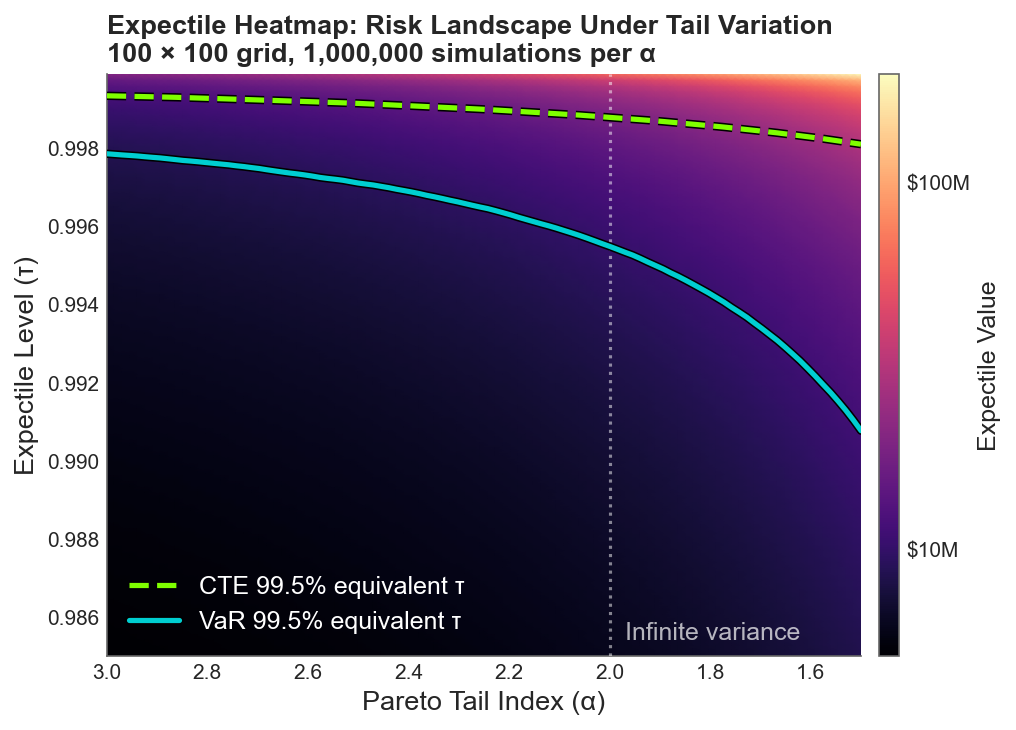

In [6]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

# --- Heatmap ---
pcm = ax.pcolormesh(
    PARETO_GRID, TAU_GRID, expectile_matrix.T / 1e6,
    cmap='magma', shading='gouraud',
    norm=LogNorm(
        vmin=expectile_matrix.min() / 1e6,
        vmax=expectile_matrix.max() / 1e6,
    ),
)

# --- Overlay VaR and CTE curves with black stroke for visibility ---
stroke = [pe.withStroke(linewidth=4, foreground='black')]

ax.plot(PARETO_GRID, cte_tau_equiv, color='#7FFF00', lw=2.5, ls='--',
        label='CTE 99.5% equivalent \u03c4', zorder=5,
        path_effects=stroke)

ax.plot(PARETO_GRID, var_tau_equiv, color='#00CED1', lw=2.5,
        label='VaR 99.5% equivalent \u03c4', zorder=5,
        path_effects=stroke)

# --- Infinite variance transition ---
ax.axvline(2.0, color='white', ls=':', lw=1.5, alpha=0.5, zorder=4)
ax.text(1.97, TAU_GRID[2], 'Infinite variance',
        color='white', fontsize=12, ha='left', va='bottom', alpha=0.7)

# --- Colorbar ---
cbar = fig.colorbar(pcm, ax=ax, pad=0.02, aspect=30, format="$%.0fM")
cbar.set_label('Expectile Value', fontsize=12)

# --- Labels ---
ax.set_xlabel('Pareto Tail Index (\u03b1)', fontsize=13)
ax.set_ylabel('Expectile Level (\u03c4)', fontsize=13)
ax.set_title('Expectile Heatmap: Risk Landscape Under Tail Variation\n'
             f'{N_PARETO} \u00d7 {N_TAU} grid, {N_SIM:,} simulations per \u03b1',
             fontweight='bold', loc='left', fontsize=13)
ax.invert_xaxis()
ax.set_xlim(3.00, 1.50)

ax.legend(loc='best', fontsize=12,
          facecolor='#1a1a2e', edgecolor='white',
          labelcolor='white', framealpha=0.8)

plt.tight_layout()
plt.savefig("cache/plot_14_expectile_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## Diagnostic: VaR and CTE Equivalent Expectile Levels

The line plot below isolates the VaR and CTE curves from the heatmap, making it easier to read the exact $\tau$ values and see how the mapping between traditional risk measures and expectiles changes with tail heaviness.

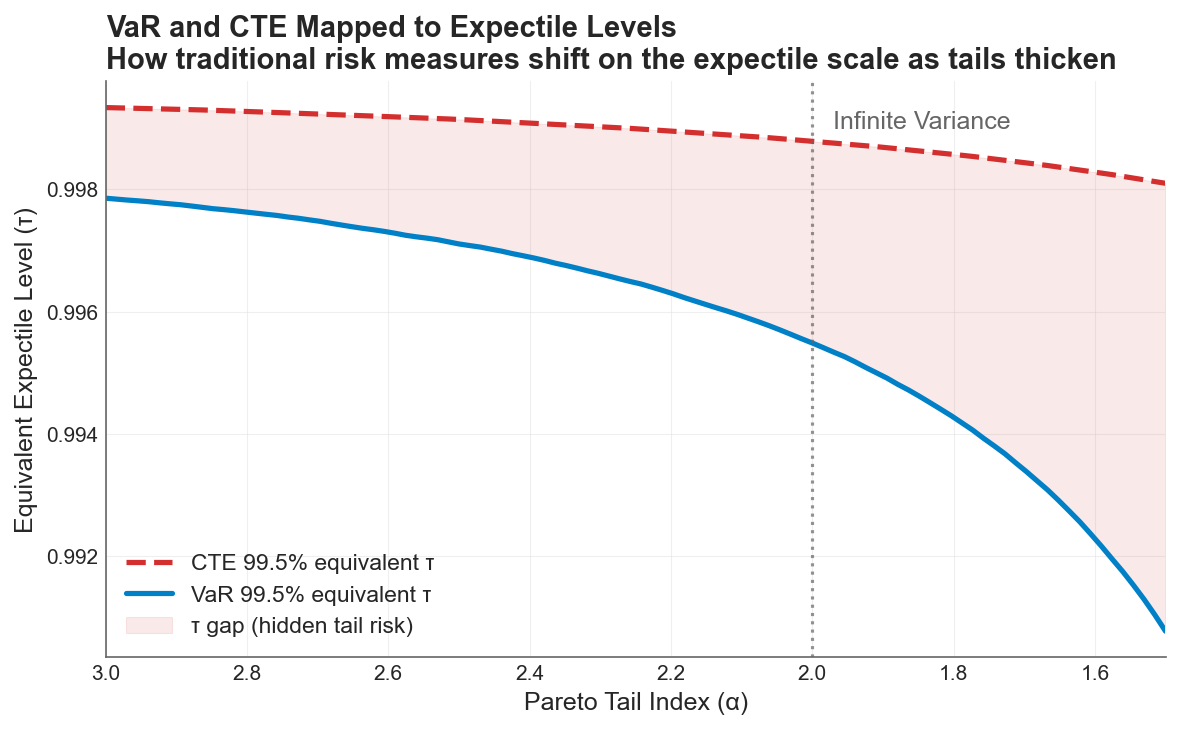

In [7]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

ax.plot(PARETO_GRID, cte_tau_equiv, '--', color=COLOR_SEQUENCE[1], lw=2.5,
        label='CTE 99.5% equivalent \u03c4')

ax.plot(PARETO_GRID, var_tau_equiv, '-', color=COLOR_SEQUENCE[0], lw=2.5,
        label='VaR 99.5% equivalent \u03c4')

ax.fill_between(PARETO_GRID, var_tau_equiv, cte_tau_equiv,
                color=COLOR_SEQUENCE[1], alpha=0.10,
                label='\u03c4 gap (hidden tail risk)')

ax.axvline(2.0, color=WSJ_COLORS['gray'], ls=':', lw=1.5, alpha=0.7)
trans = ax.get_xaxis_transform()
ax.text(1.97, 0.95, 'Infinite Variance',
        fontsize=12, color=WSJ_COLORS['gray'],
        ha='left', va='top', transform=trans)

ax.set_xlabel('Pareto Tail Index (\u03b1)', fontsize=12)
ax.set_ylabel('Equivalent Expectile Level (\u03c4)', fontsize=12)
ax.set_title('VaR and CTE Mapped to Expectile Levels\n'
             'How traditional risk measures shift on the expectile scale as tails thicken',
             fontweight='bold', loc='left', fontsize=14)
ax.legend(fontsize=11)
ax.invert_xaxis()
ax.set_xlim(3.0, 1.5)

plt.tight_layout()
plt.savefig("cache/plot_14_expectile_tau_equiv.png", dpi=150, bbox_inches='tight')
plt.show()

## Relativities of VaR, CTE, and Expectiles

The following line plot isolates the 99.5th Expectile and compares its growth rate to 99.5th VaR and CTE. The choice of 99.5th Expectile is somewhat arbitrary, but the main idea is to get a sense of how it increases relative to VaR and CTE at the same level.

The close fit of this Expectile to CTE is spurious. Other distributions or $\tau$ choices would yield different results.

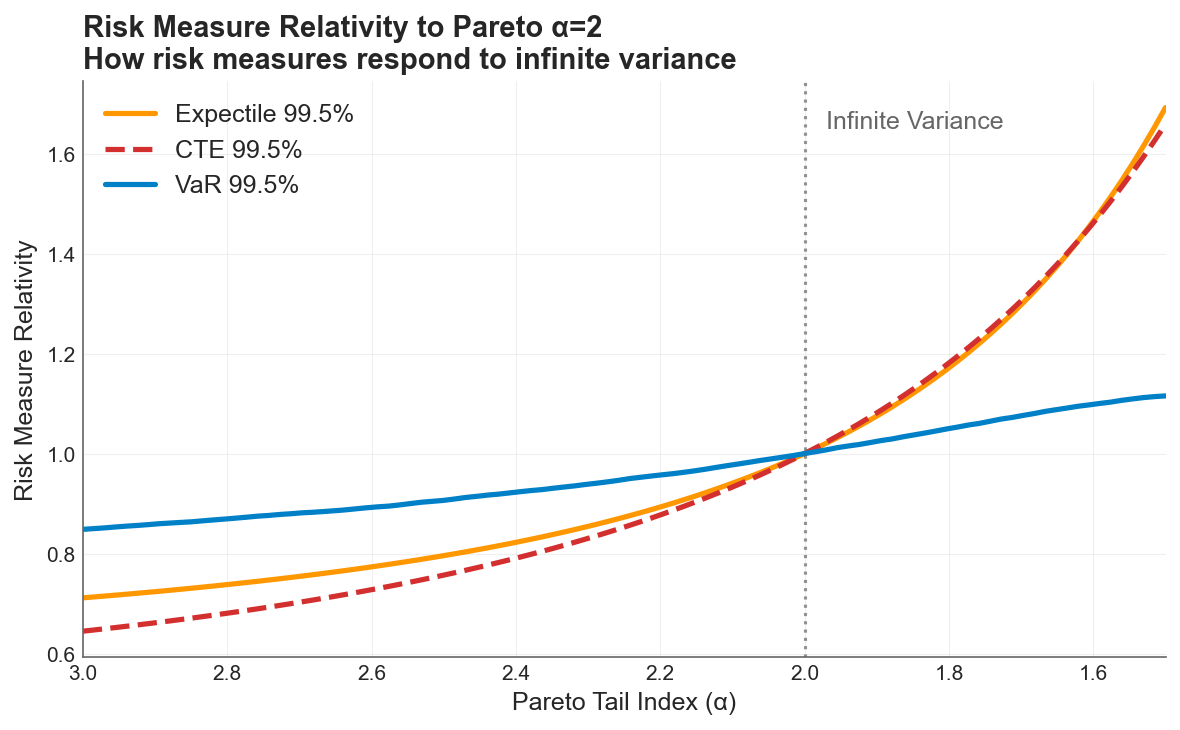

In [8]:
set_wsj_style()

closest_alpha_idx = min(enumerate(PARETO_GRID), key=lambda x: abs(2.0 - x[1]))[0]
var_close_to_alpha_2 = var_values[closest_alpha_idx ]
cte_close_to_alpha_2 = cte_values[closest_alpha_idx ]
expectile_close_to_alpha_2 = expectile_995[closest_alpha_idx ]

var_values_norm = var_values / var_close_to_alpha_2
cte_values_norm = cte_values / cte_close_to_alpha_2 
expectile_values_norm = expectile_995 / expectile_close_to_alpha_2

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

ax.plot(PARETO_GRID, expectile_values_norm, '-', color=COLOR_SEQUENCE[3], lw=2.5,
        label='Expectile 99.5%')

ax.plot(PARETO_GRID, cte_values_norm, '--', color=COLOR_SEQUENCE[1], lw=2.5,
        label='CTE 99.5%')

ax.plot(PARETO_GRID, var_values_norm, '-', color=COLOR_SEQUENCE[0], lw=2.5,
        label='VaR 99.5%')

ax.axvline(2.0, color=WSJ_COLORS['gray'], ls=':', lw=1.5, alpha=0.7)
trans = ax.get_xaxis_transform()
ax.text(1.97, 0.95, 'Infinite Variance',
        fontsize=12, color=WSJ_COLORS['gray'],
        ha='left', va='top', transform=trans)

ax.set_xlabel('Pareto Tail Index (\u03b1)', fontsize=12)
ax.set_ylabel('Risk Measure Relativity', fontsize=12)
ax.set_title('Risk Measure Relativity to Pareto \u03b1=2\n'
             'How risk measures respond to infinite variance',
             fontweight='bold', loc='left', fontsize=14)
ax.legend(fontsize=12)
ax.invert_xaxis()
ax.set_xlim(3.0, 1.5)

plt.tight_layout()
plt.savefig("cache/plot_14_risk_measure_relativity.png", dpi=150, bbox_inches='tight')
plt.show()

## Interpretation & Conclusion

### The Expectile Surface

The heatmap reveals the complete risk landscape:

- At **low $\tau$** (bottom), all Pareto $\alpha$ values produce similar expectile values near the **mean** (~\$1.15M), confirming that expected losses are held constant across the sweep.
- At **high $\tau$** (top), expectile values **diverge dramatically**: heavier tails (lower $\alpha$) produce vastly larger expectiles, reflecting the explosive growth in tail risk.
- The logarithmic color scale makes the **phase transition at $\alpha = 2$** visible as a steepening of the gradient: below $\alpha = 2$, where variance becomes infinite, expectile values at high $\tau$ grow much faster.

### VaR and CTE as Expectile Contours

The cyan VaR curve and green CTE curve locate two traditional risk measures on the expectile surface. Key observations:

1. **CTE sits at higher $\tau$ than VaR**: Since CTE exceeds VaR at every $\alpha$, the CTE-equivalent expectile level is always above the VaR-equivalent level. The vertical gap between curves measures how much additional tail sensitivity CTE provides over VaR, expressed in expectile units.

2. **Both curves shift as tails thicken**: As $\alpha$ decreases, both the VaR-equivalent and CTE-equivalent $\tau$ levels drop. A fixed confidence level like 99.5% captures a different fraction of the tail risk depending on how heavy the tail is, and VaR and CTE shift by different amounts, meaning their relative conservatism is not a fixed property but depends on the distributional environment.

3. **The $\alpha = 2$ transition**: The infinite-variance boundary creates a visible inflection in both curves, showing that the relationship between traditional risk measures and expectiles changes qualitatively when variance diverges.

### Risk Measure Relativities

The relativity plot normalizes all three risk measures at $\alpha = 2$ (the infinite-variance boundary) and reveals how each responds to tail thickening:

1. **VaR is nearly inert**: Across the full sweep from $\alpha = 3$ to $\alpha = 1.5$, VaR moves roughly $\pm 15\%$ from its $\alpha = 2$ value. As a pure quantile, VaR registers only whether the 99.5th percentile data point shifted. It is blind to how the mass above that point redistributed. Even the transition to infinite variance barely accelerates its response.

2. **CTE and the 99.5% Expectile respond almost identically**: Both swing from roughly 0.65$\times$ (at $\alpha = 3$) to 1.7$\times$ (at $\alpha = 1.5$), a ~160% range, and about 5$\times$ more responsive than VaR. Both measures are sensitive to tail *magnitude*, not just tail *frequency*, so they detect the redistribution of mass that VaR ignores. The near-overlap at this confidence level is specific to the 99.5% level and this loss model; at other $\tau$ values the two measures can diverge further.

3. **The $\alpha = 2$ boundary is asymmetric**: All three measures steepen past $\alpha = 2$, but VaR's acceleration is modest while the magnitude-sensitive measures explode. This asymmetry quantifies the practical difference: in the infinite-variance regime, a firm relying on VaR sees capital requirements grow slowly, while the actual tail risk (as captured by CTE or expectiles) grows far faster.

### Why This Matters

Expectiles provide a **unified framework** in which VaR, CTE, and the mean are simply different points on a continuous $\tau$ scale. This unification offers three practical advantages:

1. **Backtesting coherent risk**: Because expectiles are elicitable, a firm can backtest its coherent capital requirements using consistent scoring functions, something impossible with CTE alone (de Ita Solis et al., 2026).

2. **Tail sensitivity without ad-hoc choices**: Rather than choosing between VaR and CTE (each with known theoretical flaws), practitioners can select an expectile level $\tau$ that provides the desired balance of tail sensitivity, and both backtest and verify coherence.

3. **Ergodic implications**: Under multiplicative dynamics, a firm's time-average growth rate depends on the full shape of the loss distribution, not just a single quantile or conditional mean. Expectiles, by their global dependence on loss magnitudes, provide a natural risk measure for ergodic optimization. The relativity plot makes this concrete: VaR-based capital barely responds to tail thickening, while expectile-based capital tracks the actual growth in tail risk that drives multiplicative ruin.

### Reference

de Ita Solis, J.A., Lu, Y., Mailhot, M., & Meng, X. (2026). [Backtesting expectile: Disentangling unconditional coverage and independence properties](https://www.sciencedirect.com/science/article/pii/S2950629826000020).